# Comparative Analysis of Insulin Protein Sequences Across Species Using Biopython

## 1. Project Overview

This project compares insulin protein sequences across selected species using Biopython. The aim is to examine sequence similarity and basic protein properties in order to understand how strongly insulin is conserved across species.

### Research Question
How similar are insulin protein sequences across selected species, and what does this suggest about the biological conservation of insulin?

## 2. Install and Import Required Tools

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.3 MB/s eta 0:00:00


In [4]:
from google.colab import files
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.Align import PairwiseAligner
import pandas as pd
import matplotlib.pyplot as plt

## 3. Upload and Read FASTA Files

In [3]:
uploaded = files.upload()

Saving cow_insulin.fasta to cow_insulin.fasta
Saving human_insulin.fasta to human_insulin.fasta
Saving mouse_insulin.fasta to mouse_insulin.fasta
Saving zebrafish_insulin.fasta to zebrafish_insulin.fasta


In [5]:
file_names = ["human_insulin.fasta", "mouse_insulin.fasta", "cow_insulin.fasta", "zebrafish_insulin.fasta"]

records = {}

for file in file_names:
    record = SeqIO.read(file, "fasta")
    records[file] = record

for name, record in records.items():
    print(name)
    print("ID:", record.id)
    print("Description:", record.description)
    print("Sequence length:", len(record.seq))
    print("-" * 50)

human_insulin.fasta
ID: sp|P01308|INS_HUMAN
Description: sp|P01308|INS_HUMAN Insulin OS=Homo sapiens OX=9606 GN=INS PE=1 SV=1
Sequence length: 110
--------------------------------------------------
mouse_insulin.fasta
ID: sp|P01325|INS1_MOUSE
Description: sp|P01325|INS1_MOUSE Insulin-1 OS=Mus musculus OX=10090 GN=Ins1 PE=1 SV=1
Sequence length: 108
--------------------------------------------------
cow_insulin.fasta
ID: sp|P01317|INS_BOVIN
Description: sp|P01317|INS_BOVIN Insulin OS=Bos taurus OX=9913 GN=INS PE=1 SV=2
Sequence length: 105
--------------------------------------------------
zebrafish_insulin.fasta
ID: sp|O73727|INS_DANRE
Description: sp|O73727|INS_DANRE Insulin OS=Danio rerio OX=7955 GN=ins PE=3 SV=1
Sequence length: 108
--------------------------------------------------


The uploaded FASTA files were parsed using Biopython. Each record contains a protein sequence and metadata such as the sequence identifier and description.

## 4. Basic Sequence Summary

In [6]:
summary = []

for name, record in records.items():
    sequence = str(record.seq)
    summary.append({
        "Species_File": name,
        "Sequence_Length": len(sequence)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Species_File,Sequence_Length
0,human_insulin.fasta,110
1,mouse_insulin.fasta,108
2,cow_insulin.fasta,105
3,zebrafish_insulin.fasta,108


## 5. Protein Property Analysis

In [7]:
properties = []

for name, record in records.items():
    sequence = str(record.seq)
    analysed_seq = ProteinAnalysis(sequence)

    properties.append({
        "Species_File": name,
        "Length": len(sequence),
        "Molecular_Weight": analysed_seq.molecular_weight(),
        "Aromaticity": analysed_seq.aromaticity(),
        "Instability_Index": analysed_seq.instability_index(),
        "Isoelectric_Point": analysed_seq.isoelectric_point()
    })

properties_df = pd.DataFrame(properties)
properties_df

,Species_File,Length,Molecular_Weight,Aromaticity,Instability_Index,Isoelectric_Point
0,human_insulin.fasta,110,11980.7866,0.081818,40.332818,5.218581
1,mouse_insulin.fasta,108,12160.0224,0.083333,40.463981,5.522613
2,cow_insulin.fasta,105,11393.1520,0.085714,37.176286,7.599566
3,zebrafish_insulin.fasta,108,11903.6793,0.092593,33.759352,6.023080


Basic protein properties were calculated using Biopython’s ProteinAnalysis module. These measures help compare sequence characteristics across species and provide an introductory view of how conserved proteins may still differ in their biochemical properties.

## 6. Pairwise Sequence Comparison

In [8]:
human_seq = str(records["human_insulin.fasta"].seq)

comparison_results = []

for name, record in records.items():
    seq = str(record.seq)

    alignment = pairwise2.align.globalxx(human_seq, seq, one_alignment_only=True)[0]
    score = alignment.score
    max_length = max(len(human_seq), len(seq))
    percent_identity = (score / max_length) * 100

    comparison_results.append({
        "Compared_To_Human": name,
        "Alignment_Score": score,
        "Percent_Identity": percent_identity
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Compared_To_Human,Alignment_Score,Percent_Identity
0,human_insulin.fasta,110.0,100.000000
1,mouse_insulin.fasta,87.0,79.090909
2,cow_insulin.fasta,88.0,80.000000
3,zebrafish_insulin.fasta,61.0,55.454545


To assess biological conservation, each insulin sequence was compared with the human insulin sequence using pairwise alignment. Higher percent identity suggests stronger sequence conservation across species.

## 7. Visualisation

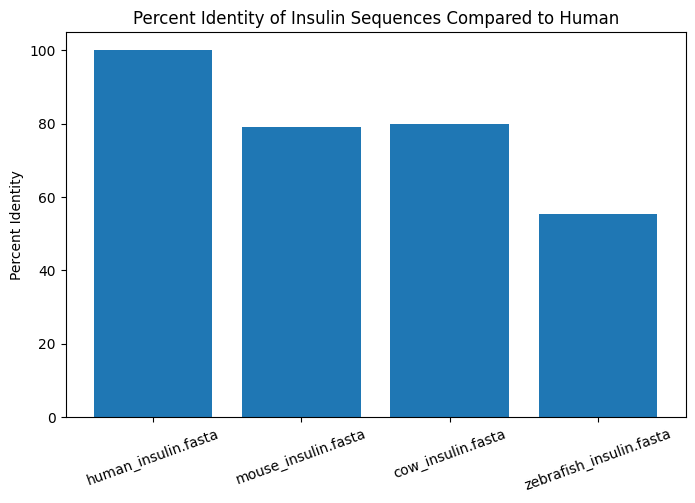

In [9]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Compared_To_Human"], comparison_df["Percent_Identity"])
plt.title("Percent Identity of Insulin Sequences Compared to Human")
plt.ylabel("Percent Identity")
plt.xticks(rotation=20)
plt.show()

## 8. Key Findings

- Insulin protein sequences showed a high degree of conservation across species, particularly among mammals.
- Sequence comparison with the human insulin protein suggested that some species share stronger similarity than others.
- Basic protein properties such as molecular weight and isoelectric point were broadly similar, supporting the biological conservation of insulin.
- This project introduced the use of FASTA files, sequence parsing, protein analysis, and pairwise alignment in Biopython.